In [1]:
import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT.EnableImplicitMT(10)

Welcome to JupyROOT 6.28/04


In [2]:
pathmc = '/rxc_lustre/ivan.cambon/TrackCalibmu_AA_tuples/MC/pO_2025/trackeffmu_pO_mc_2025.root'


tdf_mc = ROOT.RDataFrame("charmonium_mu_mu_Down_mup_Tag/DecayTree", pathmc)

In [4]:
datamc = tdf_mc.Filter("dimuon_BPVIP < 0.35 && dimuon_DOCA_12 < 0.5 &&  dimuon_PT > 2000 && mum_CHI2DOF < 1.5 && mum_P > 1000 && mum_PID_MU > 0 && mum_PT > 1500 && mup_CHI2DOF < 1.2")
datamc = datamc.Filter("abs(dimuon_TRUEID)==443")

-------------------------
Set LHCb Style - May 2021
-------------------------


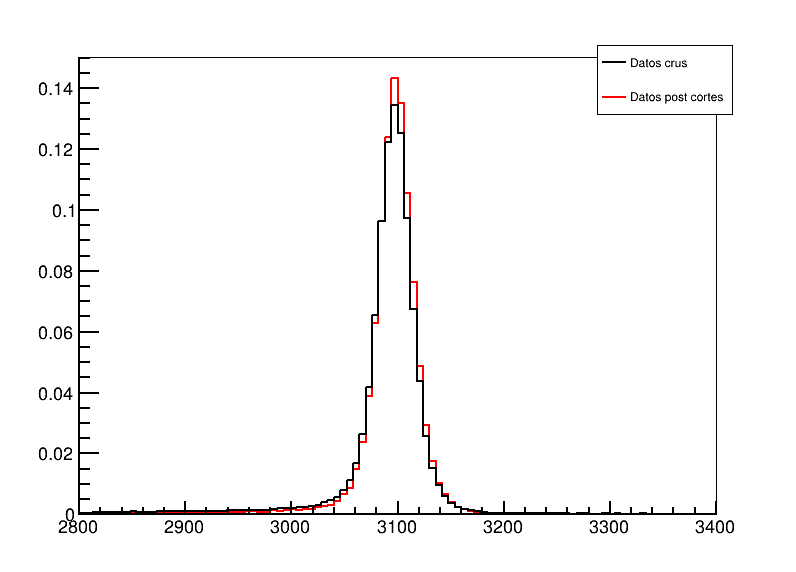

In [4]:


h_masa_antes = tdf_mc.Histo1D(("h_mass_before","Dimuon mass before cuts",100,2800,3400), "dimuon_M")
h_masa_cortes = datamc.Histo1D(("h_mass_before","Dimuon mass before cuts",100,2800,3400), "dimuon_M")
hist_before = h_masa_antes.GetValue()
hist_after  = h_masa_cortes.GetValue()

c = ROOT.TCanvas("c", "", 800, 600)

hist_before.SetLineColor(ROOT.kBlack)
hist_before.SetLineWidth(2)

hist_after.SetLineColor(ROOT.kRed)
hist_after.SetLineWidth(2)

# Debuxamos normalizado
hist_after.DrawNormalized("HIST")
hist_before.DrawNormalized("HIST SAME")

# Lenda
leg = ROOT.TLegend(0.75, 0.8, 0.92, 0.92)
leg.AddEntry(hist_before, "Datos crus", "l")
leg.AddEntry(hist_after, "Datos post cortes", "l")
leg.Draw()

# Estilo LHCb
ROOT.gROOT.ProcessLine(".L lhcbStyle.C")
ROOT.lhcbStyle()

c.Draw()

In [5]:
mass = ROOT.RooRealVar("dimuon_M", "m(#mu#mu)", 3000, 3200) 
data = datamc.AsNumpy(["dimuon_M"])
roo_data = ROOT.RooDataSet.from_numpy(
    {"dimuon_M": data["dimuon_M"]},
    [mass]
)


[#0] WARNING:DataHandling -- RooDataSet.from_numpy() Ignored 669 out-of-range events


In [6]:
# 1. Variables do sinal
mean   = ROOT.RooRealVar("mean", "mean", 3096, 3070, 3130)
sigma1 = ROOT.RooRealVar("sigma1", "sigma gauss", 8, 2, 15)  # O núcleo estreito
sigma2 = ROOT.RooRealVar("sigma2", "sigma cb", 25, 15, 80)   # As colas
alpha  = ROOT.RooRealVar("alpha", "alpha", 1.5, 0.1, 10)
n      = ROOT.RooRealVar("n", "n", 3, 1.5, 50)               # Protexemos n para que non colapse

# 2. Funcións do sinal
gauss = ROOT.RooGaussian("gauss", "Gaussian Core", mass, mean, sigma1)
cb    = ROOT.RooCBShape("cb", "Crystal Ball Tail", mass, mean, sigma2, alpha, n)

sig_frac = ROOT.RooRealVar("sig_frac", "fraction Gauss/CB", 0.5, 0, 1)

# Creamos o pdf do sinal combinado
signal = ROOT.RooAddPdf("signal", "Gauss + CB", [gauss, cb], [sig_frac])

# 3. NOVO: Fondo Exponencial
# tau controla a pendente. Comezamos nun valor lixeiramente negativo (-0.01)
tau = ROOT.RooRealVar("tau", "tau bkg", -0.01, -2.0, 0.5)
bkg = ROOT.RooExponential("bkg", "Exponential Bkg", mass, tau)

# 4. Sumamos SINAL + FONDO usando números de eventos (yields)
# Axusta os valores iniciais (10000 e 2000) se sabes que tes máis ou menos eventos en total
nsig = ROOT.RooRealVar("nsig", "number of signal events", 10000, 0, 100000)
nbkg = ROOT.RooRealVar("nbkg", "number of bkg events", 2000, 0, 100000)

model_total = ROOT.RooAddPdf("model_total", "Signal + Background", [signal, bkg], [nsig, nbkg])

# 5. Fiteamos
model_total.fitTo(roo_data)

<cppyy.gbl.RooFitResult object at 0x(nil)>

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss,cb,bkg)
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 alpha        1.50000e+00  7.00000e-01    1.00000e-01  1.00000e+01
     2 mean         3.09600e+03  6.00000e+00    3.07000e+03  3.13000e+03
     3 n            3.00000e+00  7.50000e-01    1.50000e+00  5.00000e+01
     4 nbkg         2.00000e+03  1.00000e+03    0.00000e+00  1.00000e+05
     5 nsig         1.00000e+04  5.00000e+03    0.00000e+00  1.00000e+05
     6 sig_frac     5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     7 sigma1       8.00000e+00  1.30000e+00    2.00000e+00  1.500

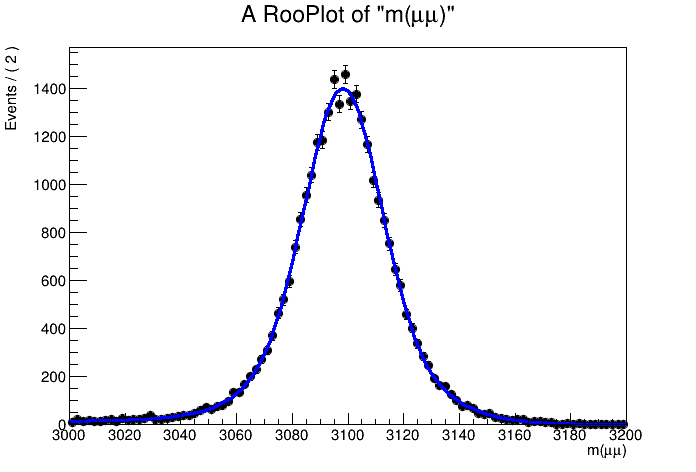

In [7]:
frame = mass.frame()

roo_data.plotOn(frame)
model_total.plotOn(frame)   # ou gauss

c = ROOT.TCanvas()
frame.Draw()
c.Draw()

[#1] INFO:Plotting -- RooAbsPdf::plotOn(model_total) directly selected PDF components: (bkg)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model_total) indirectly selected PDF components: ()
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model_total) directly selected PDF components: (signal)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model_total) indirectly selected PDF components: (gauss,cb)


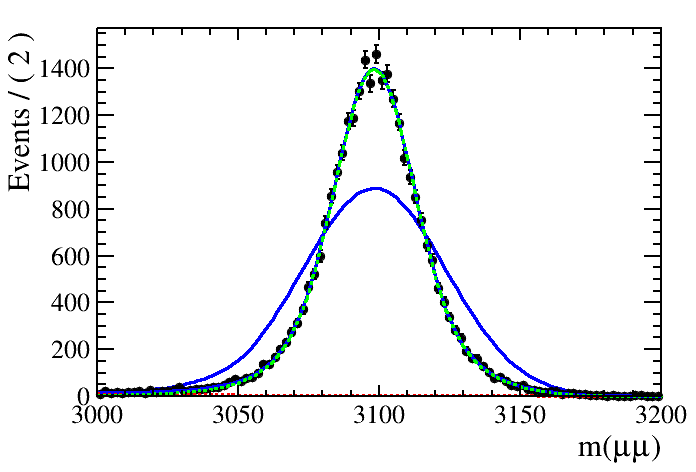

In [53]:
# Debuxa os datos e o modelo total (a túa liña azul)
roo_data.plotOn(frame)
model_total.plotOn(frame)

# Debuxa SÓ a exponencial punteada en vermello
model_total.plotOn(frame, ROOT.RooFit.Components("bkg"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))

# Debuxa SÓ o sinal (opcional, por exemplo en verde)
model_total.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

c = ROOT.TCanvas()
frame.Draw()
c.Draw()